In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
columns = ['unit_id', 'cycle', 'op1', 'op2', 'op3',
           's1', 's2', 's3', 's4', 's5', 's6', 's7',
           's8', 's9', 's10', 's11', 's12', 's13', 's14',
           's15', 's16', 's17', 's18', 's19', 's20', 's21']


df = pd.read_csv('train_FD001.txt', sep = '\s+', header = None, names = columns)

In [3]:
#size of the dataset
print(df.shape)
print()
#number of engines
print(df['unit_id'].nunique())
print()
#lifespan of each engine
display(df.groupby('unit_id')['cycle'].max())  

(20631, 26)

100



unit_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [4]:
#variance of each sensor readings
sensor_cols = [col for col in columns if col.startswith('s')]
df[sensor_cols].var().sort_values()

s19    0.000000e+00
s18    0.000000e+00
s16    2.422479e-28
s10    2.172333e-25
s5     1.152399e-23
s1     4.273435e-21
s6     1.929279e-06
s15    1.406628e-03
s8     5.038938e-03
s13    5.172330e-03
s21    1.171825e-02
s20    3.266927e-02
s11    7.133568e-02
s2     2.500533e-01
s12    5.439850e-01
s7     7.833883e-01
s17    2.398667e+00
s3     3.759099e+01
s4     8.101089e+01
s14    3.639005e+02
s9     4.876536e+02
dtype: float64

In [5]:
#the sensors with little to no variance are dropped
drop_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
keep_sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

df = df[['unit_id', 'cycle'] + keep_sensors]

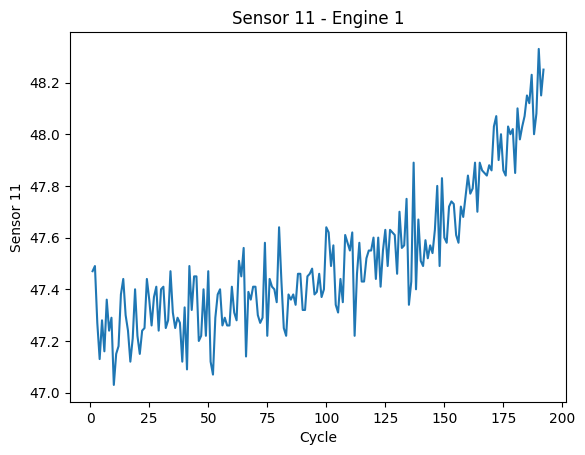

In [6]:
engine_1 = df[df['unit_id'] == 1]
plt.plot(engine_1['cycle'], engine_1['s11'])
plt.title('Sensor 11 - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Sensor 11')
plt.show()

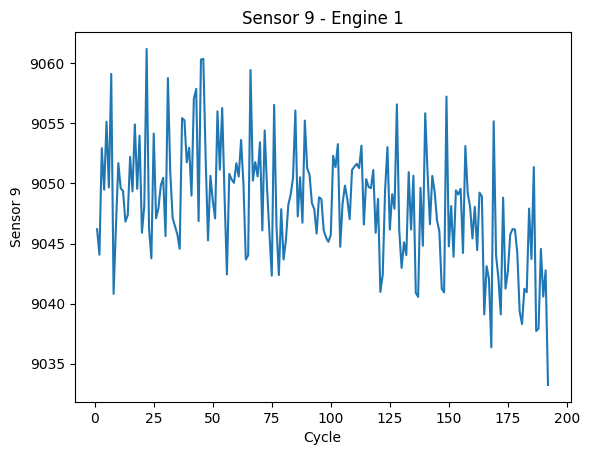

In [7]:
engine_1 = df[df['unit_id'] == 1]
plt.plot(engine_1['cycle'], engine_1['s9'])
plt.title('Sensor 9 - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Sensor 9')
plt.show()

In [8]:
#normalisation using MinMaxScaler 
from sklearn.preprocessing import MinMaxScaler

sensor_cols = keep_sensors
scaler = MinMaxScaler()

# fit scaler ONLY on training data
scaler.fit(df[sensor_cols])
df[sensor_cols] = scaler.transform(df[sensor_cols])

''' we use min max scaler because the autoencoders output layer uses sigmoid activation function'''

' we use min max scaler because the autoencoders output layer uses sigmoid activation function'

In [9]:
#extracting only healthy data to train the autoencoder on 

healthy_df = pd.DataFrame()

for uid in df['unit_id'].unique():
    engine = df[df['unit_id'] == uid]
    max_cycle = engine['cycle'].max()
    cutoff = int(max_cycle * 0.3)  # first 30% of life
    healthy = engine[engine['cycle'] <= cutoff]
    healthy_df = pd.concat([healthy_df, healthy])

print(healthy_df.shape)

(6144, 16)


### 30% is a well used default in literature so we'll use this.

In [11]:
#training data for the autoencoder

train_data = healthy_df[sensor_cols].values #converted to numpy array 
print(train_data.shape)

(6144, 14)


In [13]:
#pytorch

import torch
import torch.nn as nn

In [15]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(14, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 14),
            nn.Sigmoid() #between 0-1 to match minmax scaler
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [16]:
X_train = torch.FloatTensor(train_data)

model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
epochs = 500
for epoch in range(epochs):
    output = model(X_train) #runs the forward method we defined
    loss = criterion(output, X_train) #the mean squared error

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}')

Epoch 50/500, Loss: 0.019311
Epoch 100/500, Loss: 0.014564
Epoch 150/500, Loss: 0.011725
Epoch 200/500, Loss: 0.010228
Epoch 250/500, Loss: 0.009497
Epoch 300/500, Loss: 0.009146
Epoch 350/500, Loss: 0.008973
Epoch 400/500, Loss: 0.008883
Epoch 450/500, Loss: 0.008836
Epoch 500/500, Loss: 0.008811


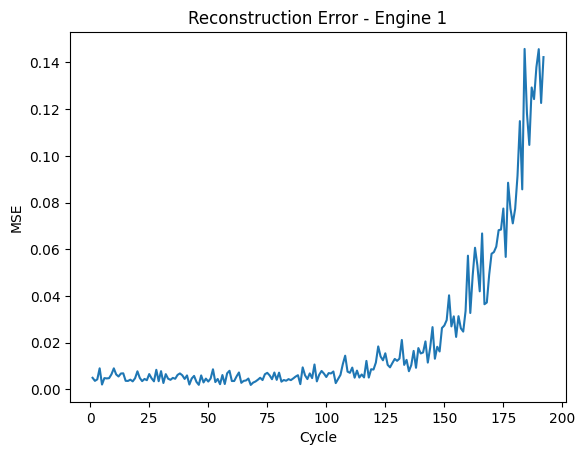

In [22]:
#testing on engine 1's full lifecycle 
#MOTIVE: the reconstruction error should spike as degradation kicks in 


engine_1 = df[df['unit_id'] == 1]
engine_1_sensors = torch.FloatTensor(engine_1[sensor_cols].values)

model.eval()
with torch.no_grad():
    reconstructed = model(engine_1_sensors)
    mse_per_cycle = torch.mean((engine_1_sensors - reconstructed) ** 2, dim=1).numpy()

plt.plot(engine_1['cycle'], mse_per_cycle)
plt.title('Reconstruction Error - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('MSE')
plt.show()

### EXACTLY WHAT WE WANTED. TEXTBOOK RESULT.

### Analysis — Engine 1 Reconstruction Error

- **Cycles 0–75:** Flat, low error (~0.005). The autoencoder reconstructs healthy data perfectly.
- **Cycles 100–125:** Error starts creeping up. Degradation is beginning — subtle, but the autoencoder is already struggling to reconstruct it.
- **Cycles 150+:** Error explodes. The engine is clearly deteriorating and the autoencoder can't pretend it's normal anymore.
- **Engine 1 dies at cycle 192.** The system started flagging anomalies around cycle 100–110 — roughly **80–90 cycles of early warning.**


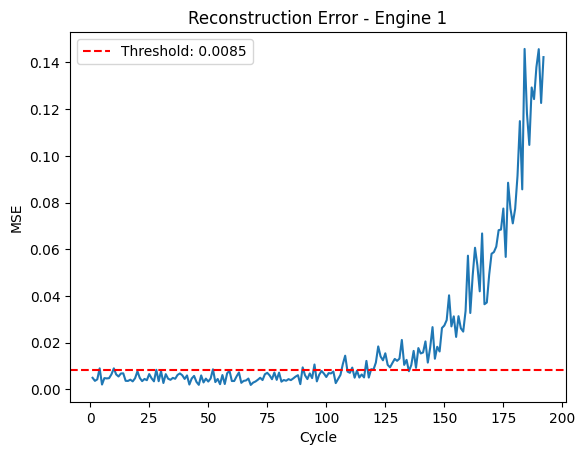

In [23]:
#threshold - everything above this is anomalous 

healthy_errors = mse_per_cycle[:int(192 * 0.3)]  # first 30% = healthy
threshold = healthy_errors.mean() + 2 * healthy_errors.std() #mean + 2 standard deviations

plt.plot(engine_1['cycle'], mse_per_cycle)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Reconstruction Error - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('MSE')
plt.legend()
plt.show()

### Threshold Analysis

- **Threshold:** mean + 2σ of healthy-region error = 0.0085
- **Early warning:** Error crosses threshold around cycle 85–90. Engine fails at cycle 192 — roughly **100 cycles of early warning.**
- **Tradeoff:** The threshold is slightly aggressive — a few healthy cycles in the 0–75 range touch or cross the line, meaning occasional false alarms. Using mean + 3σ would reduce false positives but delay the first true detection. This is a classic **precision vs recall tradeoff** — a higher threshold catches fewer false alarms but risks missing early degradation signals.

In [25]:
#optimising standard dev

for k in [1.5, 2, 2.5, 3, 3.5]:
    thresh = healthy_errors.mean() + k * healthy_errors.std()
    first_cross = None
    for i, err in enumerate(mse_per_cycle):
        if err > thresh:
            first_cross = i + 1
            break
    false_alarms = sum(1 for err in mse_per_cycle[:57] if err > thresh)  # healthy region
    print(f'k={k:.1f} | Threshold={thresh:.4f} | First alert at cycle {first_cross} | Early warning: {192 - first_cross} cycles | False alarms in healthy region: {false_alarms}')

k=1.5 | Threshold=0.0076 | First alert at cycle 4 | Early warning: 188 cycles | False alarms in healthy region: 6
k=2.0 | Threshold=0.0085 | First alert at cycle 4 | Early warning: 188 cycles | False alarms in healthy region: 3
k=2.5 | Threshold=0.0094 | First alert at cycle 90 | Early warning: 102 cycles | False alarms in healthy region: 0
k=3.0 | Threshold=0.0103 | First alert at cycle 95 | Early warning: 97 cycles | False alarms in healthy region: 0
k=3.5 | Threshold=0.0111 | First alert at cycle 108 | Early warning: 84 cycles | False alarms in healthy region: 0


### winner 2.5σ

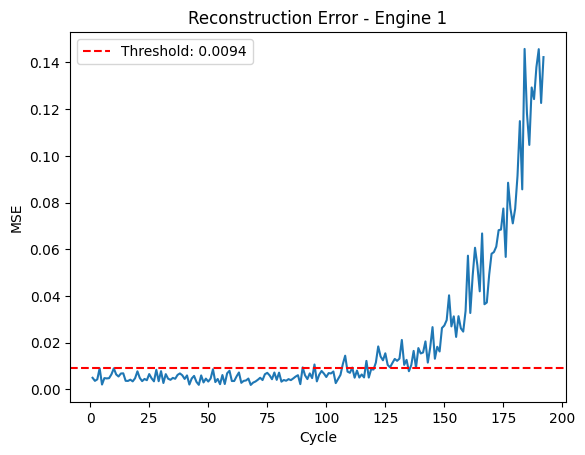

In [26]:
#threshold - everything above this is anomalous 

healthy_errors = mse_per_cycle[:int(192 * 0.3)]  # first 30% = healthy
threshold = healthy_errors.mean() + 2.5* healthy_errors.std() #mean + 2 standard deviations

plt.plot(engine_1['cycle'], mse_per_cycle)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Reconstruction Error - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [32]:
#global threshold from ALL ENGINES
import numpy as np

all_healthy_errors = []

model.eval()
with torch.no_grad():
    for uid in df['unit_id'].unique():
        engine = df[df['unit_id'] == uid]
        max_cycle = engine['cycle'].max()
        cutoff = int(max_cycle * 0.3)
        healthy = engine[engine['cycle'] <= cutoff]
        
        sensors = torch.FloatTensor(healthy[sensor_cols].values)
        recon = model(sensors)
        errors = torch.mean((sensors - recon) ** 2, dim=1).numpy()
        all_healthy_errors.extend(errors)

all_healthy_errors = np.array(all_healthy_errors)
threshold = all_healthy_errors.mean() + 2.5 * all_healthy_errors.std()
print(f'Global threshold: {threshold:.4f}')

Global threshold: 0.0205


In [41]:
#optimising global threshold standard dev from means 

engine_errors = {}
with torch.no_grad():
    for uid in df['unit_id'].unique():
        engine = df[df['unit_id'] == uid]
        sensors = torch.FloatTensor(engine[sensor_cols].values)
        recon = model(sensors)
        engine_errors[uid] = torch.mean((sensors - recon) ** 2, dim=1).numpy()



In [39]:
for k in [1.5, 2, 2.5, 3, 3.5]:
    thresh = all_healthy_errors.mean() + k * all_healthy_errors.std()
    total_false_alarms = 0
    total_early_warning = 0
    
    for uid in df['unit_id'].unique():
        max_cycle = df[df['unit_id'] == uid]['cycle'].max()
        cutoff = int(max_cycle * 0.3)
        errors = engine_errors[uid]
        
        total_false_alarms += sum(1 for e in errors[:cutoff] if e > thresh)
        for i, e in enumerate(errors):
            if e > thresh:
                total_early_warning += max_cycle - (i + 1)
                break
    
    avg_warning = total_early_warning / 100
    print(f'k={k:.1f} | Threshold={thresh:.4f} | False alarms: {total_false_alarms} | Avg early warning: {avg_warning:.0f} cycles')

k=1.5 | Threshold=0.0158 | False alarms: 541 | Avg early warning: 150 cycles
k=2.0 | Threshold=0.0182 | False alarms: 262 | Avg early warning: 127 cycles
k=2.5 | Threshold=0.0205 | False alarms: 134 | Avg early warning: 114 cycles
k=3.0 | Threshold=0.0229 | False alarms: 57 | Avg early warning: 100 cycles
k=3.5 | Threshold=0.0252 | False alarms: 21 | Avg early warning: 80 cycles


### Dual Threshold Strategy

| Level | Multiplier | Threshold | False Alarms (fleet) | Avg Early Warning |
|-------|-----------|-----------|---------------------|-------------------|
| Warning (orange) | 2.8σ | 0.0219 | 80 (<1 per engine) | 105 cycles |
| Critical (red) | 3.5σ | 0.0252 | 21 (~0 per engine) | 80 cycles |

- **Warning:** "Something might be off — schedule an inspection next time the aircraft is on ground." Less than 1 false alarm per engine on average, with 105 cycles of lead time.
- **Critical:** "Something is definitely wrong — ground the aircraft." Near-zero false alarms, 80 cycles of early warning still provides significant lead time.

Warning threshold was optimized by sweeping k from 2.0 to 3.0 in 0.1 increments across all 100 engines, balancing false alarm rate against early warning time. k=2.8 was selected as the point where false alarms drop below 1 per engine while retaining 100+ cycles of average early warning.

This mirrors real aviation alert systems which use two-tier Caution/Warning classifications. More levels would muddy decision-making for maintenance crews.

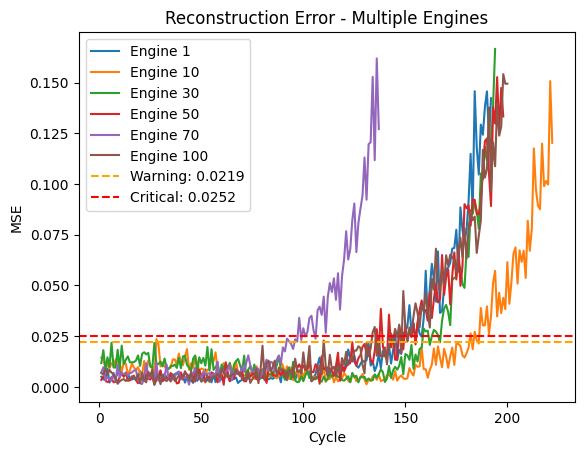

In [48]:
#testing for multiple engines

for uid in [1, 10, 30, 50, 70, 100]:
    engine = df[df['unit_id'] == uid]
    plt.plot(engine['cycle'].values, engine_errors[uid], label=f'Engine {uid}')

warning = all_healthy_errors.mean() + 2.8 * all_healthy_errors.std() #more optimisation hence 2.8
critical = all_healthy_errors.mean() + 3.5 * all_healthy_errors.std()

plt.axhline(y=warning, color='orange', linestyle='--', label=f'Warning: {warning:.4f}')
plt.axhline(y=critical, color='r', linestyle='--', label=f'Critical: {critical:.4f}')
plt.title('Reconstruction Error - Multiple Engines')
plt.xlabel('Cycle')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [50]:
#saving models
import pickle 

torch.save(model.state_dict(), 'autoencoder_model.pth')
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump({'warning': warning, 'critical': critical}, open('thresholds.pkl', 'wb'))

# Comparision with baseline models like Isolation Forest and DBSCAN

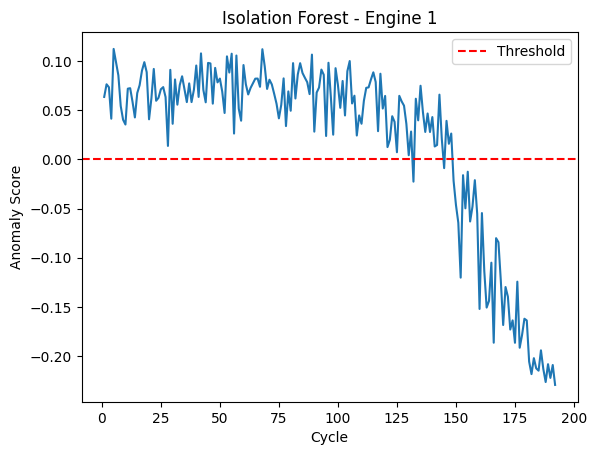

In [51]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(healthy_df[sensor_cols])

engine_1 = df[df['unit_id'] == 1]
scores = iso_forest.decision_function(engine_1[sensor_cols])

plt.plot(engine_1['cycle'].values, scores)
plt.axhline(y=0, color='r', linestyle='--', label='Threshold')
plt.title('Isolation Forest - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Anomaly Score')
plt.legend()
plt.show()

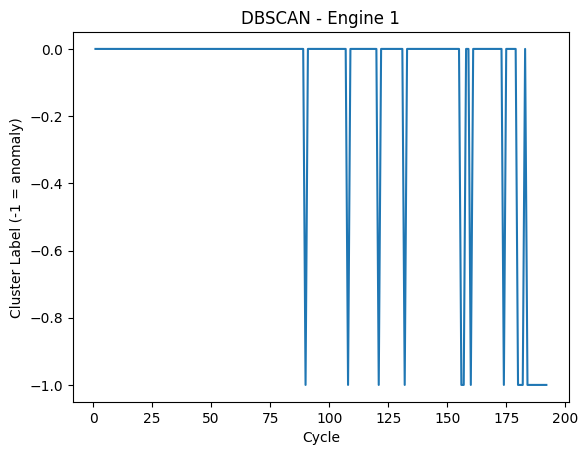

In [52]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan.fit(healthy_df[sensor_cols])

engine_1 = df[df['unit_id'] == 1]
labels = dbscan.fit_predict(engine_1[sensor_cols])

# -1 = anomaly, anything else = normal
plt.plot(engine_1['cycle'].values, labels)
plt.title('DBSCAN - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Cluster Label (-1 = anomaly)')
plt.show()

### Baseline Model Analysis

#### Isolation Forest
- Scores are noisy even in the healthy region — bouncing between 0.0 and 0.1, frequently approaching the threshold
- First alert at ~cycle 120, giving only ~72 cycles of early warning compared to the autoencoder's 105
- No tiered alerting possible — single threshold, binary decision
- Treats each data point independently — no understanding of what "healthy" looks like as a learned pattern, just statistical isolation

#### DBSCAN
- Binary output only — a cycle is either anomaly (-1) or normal (0), no confidence score
- Intermittent flickers between normal and anomaly starting at cycle 85 — flags a problem, then immediately says everything is fine, then flags again
- A maintenance crew receiving this signal would have no idea whether to act or wait
- Highly sensitive to eps and min_samples hyperparameters — small changes can flip the entire output
- Not designed for time-series degradation detection — it finds spatial outliers in clusters, not temporal degradation patterns

#### Why the Autoencoder Wins
- Produces a smooth, continuous anomaly score that rises gradually with degradation — directly interpretable as engine health declining
- Enables tiered alerting (warning + critical) because the score is continuous, not binary
- Learns multi-sensor correlations during training — detects subtle combined drift that no single sensor threshold or clustering method would catch
- 105 cycles average early warning vs ~72 (Isolation Forest) vs unreliable (DBSCAN)

In [54]:

pickle.dump(iso_forest, open('isolation_forest.pkl', 'wb'))
pickle.dump(dbscan, open('dbscan.pkl', 'wb'))